In [79]:
import numpy as np                  # Numerical computations and arrays
import pandas as pd                 # Data loading and tabular data handling

from sklearn.tree import DecisionTreeClassifier      # Single decision tree model to start the first tree
from sklearn.ensemble import RandomForestClassifier  # Ensemble of trees (bagging)
from sklearn.model_selection import train_test_split # Split data into train/test
from sklearn.metrics import accuracy_score           # Measure classification accuracy

from xgboost import XGBClassifier   # Gradient boosting with decision trees
from xgboost.callback import EarlyStopping


import matplotlib.pyplot as plt     # Data visualization 
plt.style.use('default')            # Default plot style used aldo for visualization 

RANDOM_STATE = 55                   # Fixed seed for reproducible results


In [25]:
# Load the dataset using pandas
df = pd.read_csv("heart.csv")

In [26]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

In [28]:
print(df.columns)


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [ ]:
df = pd.get_dummies(df, columns=cat_variables, prefix=cat_variables) # convert every feature to hot coading 0 or one true or false  and filter them after the target to each caracters 


In [30]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [31]:
features = [x for x in df.columns if x not in 'HeartDisease']

In [33]:
print(features)


['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [35]:
print(len(features))

20


In [36]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.
    
    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.
    
    Read more in the :ref:`User Guide <cross_validation>`.
    
    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.
    
    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to

In [37]:
X_train, X_val, y_train, y_val = train_test_split(df[features], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

In [ ]:
print(f'train samples: {len(X_train)}')
print(f'validation samples: {len(X_val)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')  # calculate the real postivive statues for patients 

train samples: 734
validation samples: 184
target proportion: 0.5518


In [42]:
min_samples_split_list = [2,10,30,50,100,200,300,700] #The minimum number of samples within a node to allow it to divide
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit. #Maximum depth allowed for the tree and none mean when i have no samples in last leafe



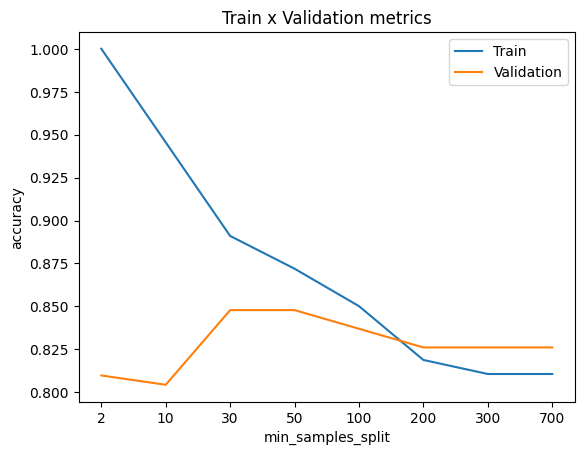

In [ ]:
accuracy_list_train = [] # create a list to record  train accuracy
accuracy_list_val = [] # ctrae al list to record validation accuracy 
for min_samples_split in min_samples_split_list: # we strat here to bulid a decision tree using all valuables number for spliiting
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)  # here we start to train the tree 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset which you didn't see it this happen because when i write fit one line above im not menthined that the tree should learn from validation data  
    accuracy_train = accuracy_score(predictions_train,y_train) #cmake comparison between the real data and datal which i caulated
    accuracy_val = accuracy_score(predictions_val,y_val) # make comparison between the real data and datal which i caulated
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) # explained at your notebook  AI2
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

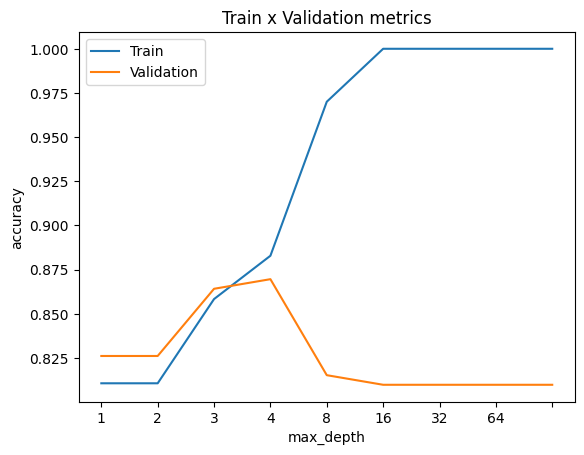

In [43]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

In [44]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 4,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [45]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}")
print(f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.8665
Metrics validation:
	Accuracy score: 0.8696


In [49]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

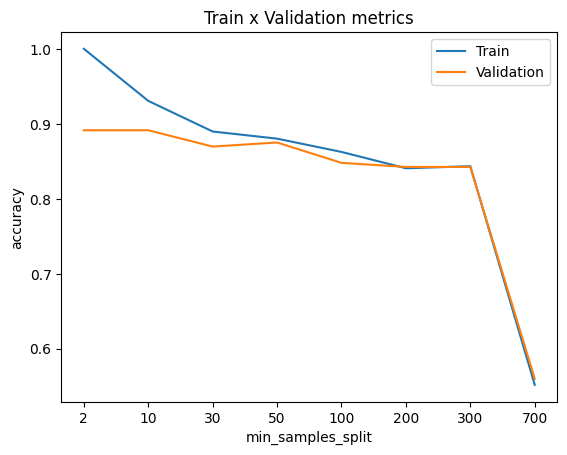

In [50]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

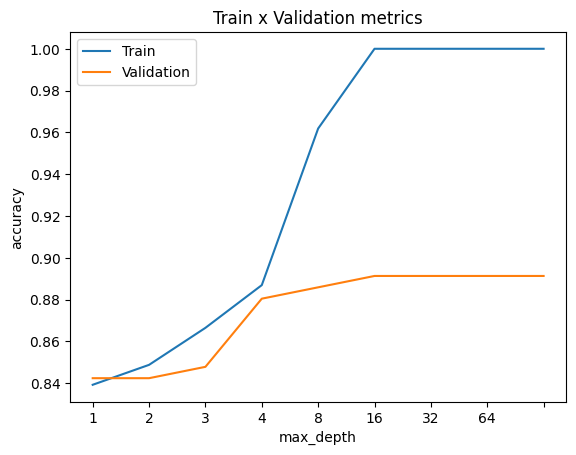

In [47]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

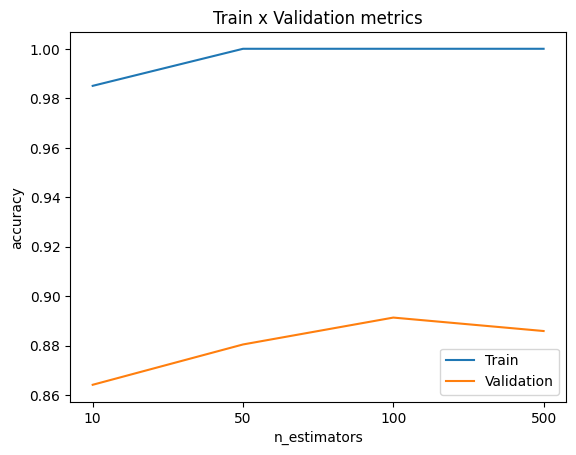

In [51]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

In [52]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 16, 
                                             min_samples_split = 10).fit(X_train,y_train)

In [53]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9360
Metrics test:
	Accuracy score: 0.8967


In [54]:
n = int(len(X_train) * 0.8)
X_train_fit = X_train[:n]
y_train_fit = y_train[:n]
X_train_eval = X_train[n:]
y_train_eval = y_train[n:]



In [68]:
xgb_model = XGBClassifier(
    n_estimators = 500, # make number of trees we use one tree and next one update the mistake in the tree before it 
    learning_rate = 0.1, #learning rate of mistakes which used to upadte the mistakes
    verbosity = 1, # work as indicators for my procss what is the mistake now just for visualization where im i now 
    random_state = RANDOM_STATE,
    early_stopping_rounds=10
)


In [64]:
conda install -c conda-forge xgboost


3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: g:\conda\envs\ml1_311

  added / updated specs:
    - xgboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |            2_gnu          48 KB  conda-forge
    ca-certificates-2025.11.12 |       h4c7d964_0         149 KB  conda-forge
    joblib-1.5.3               |     pyhd8ed1ab_0         221 KB  conda-forge
    libblas-3.11.0             |   5_hf2e6a31_mkl          66 KB  conda-forge
    libcblas-3.11.0            |   5_h2a3cdd5_mkl          66 KB  conda-forge
    libgomp-15.2.0             |      h8ee18e1_16         648 KB  conda-forge
    libhwloc-2.12.1            |default_h88281d1_1000         2.3 MB  conda-forge
    libiconv-1.18              |       hc1393d2_2       



==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [70]:
xgb_model.fit(
    X_train_fit, # used to build up the continous trees and calcualte the residuals which used for caculate the mistake and coorect the errors 
    y_train_fit,  # used to build up the continous trees and calcualte the residuals which used for caculate the mistake and coorect the errors 
    eval_set = [(X_train_eval, y_train_eval)], # evaluate each tree depend on the x_train and y_train 
   
)


[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [71]:
xgb_model.best_iteration

17

In [72]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533


In [85]:
def predict_patient_readable(xgb_model, X_train_columns, patient_dict):
    """
    Predict heart disease risk for a single patient and return a human-readable result.
    """

    # Check for missing input values
    missing_fields = [key for key, value in patient_dict.items() if value is None]
    if missing_fields:
        return {
            "Diagnosis": "Incomplete data",
            "Confidence": "N/A",
            "Recommendation": f"Please fill the following fields: {', '.join(missing_fields)}"
        }

    # Convert patient data to DataFrame
    df = pd.DataFrame([patient_dict])

    # Categorical features used during training
    categorical_features = [
        'Sex',
        'ChestPainType',
        'RestingECG',
        'ExerciseAngina',
        'ST_Slope'
    ]

    # Apply one-hot encoding
    df = pd.get_dummies(df, columns=categorical_features)

    # Add any missing columns from training data
    for column in X_train_columns:
        if column not in df.columns:
            df[column] = 0

    # Ensure column order matches training data
    df = df[X_train_columns]

    # Generate prediction probability
    probability = xgb_model.predict_proba(df)[0][1]
    prediction = int(probability >= 0.5)

    # Create user-friendly output
    if prediction == 1:
        diagnosis = "High risk of heart disease"
        recommendation = "Consult a cardiologist for further evaluation"
    else:
        diagnosis = "Low risk of heart disease"
        recommendation = "Maintain a healthy lifestyle and regular checkups"

    return {
        "Diagnosis": diagnosis,
        "Confidence": f"{probability * 100:.1f}%",
        "Recommendation": recommendation
    }


In [86]:
patient_input = {
    "Age": 54,                 # Patient age
    "Sex": "M",                # Sex: M = Male, F = Female
    "ChestPainType": "NAP",    # Chest pain type: ATA, NAP, ASY, TA
    "RestingBP": 150,          # Resting blood pressure (mm Hg)
    "Cholesterol": 195,        # Serum cholesterol (mg/dL)
    "FastingBS": 0,            # Fasting blood sugar: 1 if > 120 mg/dL, else 0
    "RestingECG": "Normal",    # Resting ECG results: Normal, ST, LVH
    "MaxHR": 122,              # Maximum heart rate achieved
    "ExerciseAngina": "N",     # Exercise-induced angina: Y = Yes, N = No
    "Oldpeak": 0.0,            # ST depression induced by exercise
    "ST_Slope": "Up"           # Slope of the peak exercise ST segment: Up, Flat, Down
}


In [87]:
result = predict_patient_readable(
    xgb_model,
    X_train.columns,
    patient_input
)

for key, value in result.items():
    print(f"{key}: {value}")


Diagnosis: Low risk of heart disease
Confidence: 9.3%
Recommendation: Maintain a healthy lifestyle and regular checkups
